# DWTS 数据预处理

本Notebook对《与星共舞》(Dancing with the Stars) 第1-34季数据进行全面预处理。

**重点关注**：
1. 缺失值处理（N/A vs 0 vs 空值）
2. 评分尺度变化（1-10范围，含小数）
3. 赛季差异（参赛人数、周数、评委人数）
4. 特殊事件（中途退赛、双淘汰、无淘汰赛）

## 第一步：数据加载与初探

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 读取数据
df = pd.read_csv('../../2026_MCM_Problem_C_Data.csv')

print(f"数据形状: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f"\n列名:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

数据形状: 421 行 × 53 列

列名:
  1. celebrity_name
  2. ballroom_partner
  3. celebrity_industry
  4. celebrity_homestate
  5. celebrity_homecountry/region
  6. celebrity_age_during_season
  7. season
  8. results
  9. placement
  10. week1_judge1_score
  11. week1_judge2_score
  12. week1_judge3_score
  13. week1_judge4_score
  14. week2_judge1_score
  15. week2_judge2_score
  16. week2_judge3_score
  17. week2_judge4_score
  18. week3_judge1_score
  19. week3_judge2_score
  20. week3_judge3_score
  21. week3_judge4_score
  22. week4_judge1_score
  23. week4_judge2_score
  24. week4_judge3_score
  25. week4_judge4_score
  26. week5_judge1_score
  27. week5_judge2_score
  28. week5_judge3_score
  29. week5_judge4_score
  30. week6_judge1_score
  31. week6_judge2_score
  32. week6_judge3_score
  33. week6_judge4_score
  34. week7_judge1_score
  35. week7_judge2_score
  36. week7_judge3_score
  37. week7_judge4_score
  38. week8_judge1_score
  39. week8_judge2_score
  40. week8_judge3_score
  4

In [3]:
# 查看数据基本信息
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   celebrity_name                421 non-null    object 
 1   ballroom_partner              421 non-null    object 
 2   celebrity_industry            421 non-null    object 
 3   celebrity_homestate           365 non-null    object 
 4   celebrity_homecountry/region  421 non-null    object 
 5   celebrity_age_during_season   421 non-null    int64  
 6   season                        421 non-null    int64  
 7   results                       421 non-null    object 
 8   placement                     421 non-null    int64  
 9   week1_judge1_score            421 non-null    float64
 10  week1_judge2_score            421 non-null    float64
 11  week1_judge3_score            407 non-null    float64
 12  week1_judge4_score            81 non-null     float64
 13  week2

In [4]:
# 查看前几行
df.head(10)

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,week1_judge2_score,week1_judge3_score,week1_judge4_score,week2_judge1_score,week2_judge2_score,week2_judge3_score,week2_judge4_score,week3_judge1_score,week3_judge2_score,week3_judge3_score,week3_judge4_score,week4_judge1_score,week4_judge2_score,week4_judge3_score,week4_judge4_score,week5_judge1_score,week5_judge2_score,week5_judge3_score,week5_judge4_score,week6_judge1_score,week6_judge2_score,week6_judge3_score,week6_judge4_score,week7_judge1_score,week7_judge2_score,week7_judge3_score,week7_judge4_score,week8_judge1_score,week8_judge2_score,week8_judge3_score,week8_judge4_score,week9_judge1_score,week9_judge2_score,week9_judge3_score,week9_judge4_score,week10_judge1_score,week10_judge2_score,week10_judge3_score,week10_judge4_score,week11_judge1_score,week11_judge2_score,week11_judge3_score,week11_judge4_score
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.00,7.00,6.00,NaN,8.00,9.00,9.00,NaN,9.00,8.00,7.00,NaN,7.00,8.00,6.00,NaN,9.00,9.00,9.00,NaN,9.00,9.00,9.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.00,4.00,4.00,NaN,5.00,6.00,6.00,NaN,6.00,7.00,8.00,NaN,9.00,9.00,8.00,NaN,8.50,7.50,7.50,NaN,8.50,9.50,9.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.00,7.00,6.00,NaN,5.00,4.00,5.00,NaN,5.00,4.00,4.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,1,Eliminated Week 4,4,7.00,6.00,7.00,NaN,8.00,8.00,8.00,NaN,8.00,9.00,9.00,NaN,7.00,9.00,9.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.00,7.00,6.00,NaN,8.00,7.00,6.00,NaN,7.00,7.00,8.00,NaN,7.00,6.00,7.00,NaN,8.50,7.00,7.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Trista Sutter,Louis van Amstel,TV Personality,Indiana,United States,32,1,Eliminated Week 2,6,6.00,6.00,6.00,NaN,6.00,7.00,6.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Tatum O'Neal,Nick Kosovich,Actor/Actress,California,United States,42,2,Eliminated Week 2,9,7.00,8.00,8.00,NaN,5.00,6.00,6.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Tia Carrere,Maksim Chmerkoskiy,Actor/Actress,Hawaii,United States,39,2,Eliminated Week 5,6,6.00,7.00,7.00,NaN,7.00,8.00,7.00,NaN,9.00,8.00,9.00,NaN,9.00,8.00,8.00,NaN,7.00,7.00,8.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,George Hamilton,Edyta Sliwinska,Actor/Actress,Tennessee,United States,66,2,Eliminated Week 6,5,7.00,5.00,6.00,NaN,8.00,7.00,7.00,NaN,7.00,7.00,8.00,NaN,7.00,7.00,7.00,NaN,8.00,8.00,8.00,NaN,8.00,7.00,8.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Lisa Rinna,Louis van Amstel,Actor/Actress,California,United States,42,2,Eliminated Week 7,4,5.00,7.00,7.00,NaN,6.00,7.00,7.00,NaN,8.00,8.00,9.00,NaN,9.00,9.00,8.00,NaN,7.00,9.00,9.00,NaN,9.00,9.00,9.00,NaN,8.50,9.00,9.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1 数据结构分析

数据包含以下类型的列：
- **基本信息**: celebrity_name, ballroom_partner, celebrity_industry, celebrity_homestate, celebrity_homecountry/region, celebrity_age_during_season
- **赛季信息**: season, results, placement
- **评委得分**: week1-11的judge1-4得分（共44列）

In [5]:
# 分离元数据列和得分列
meta_cols = ['celebrity_name', 'ballroom_partner', 'celebrity_industry', 
             'celebrity_homestate', 'celebrity_homecountry/region', 
             'celebrity_age_during_season', 'season', 'results', 'placement']

score_cols = [col for col in df.columns if 'judge' in col]

print(f"元数据列数: {len(meta_cols)}")
print(f"得分列数: {len(score_cols)}")
print(f"\n得分列结构: {len(score_cols)//4} 周 × 4 位评委")

元数据列数: 9
得分列数: 44

得分列结构: 11 周 × 4 位评委


## 第二步：缺失值深度分析

根据题目说明，数据中的特殊值有三种含义：
1. **N/A**: (a) 无第4位评委；(b) 该季未播出的周次
2. **0**: 选手已被淘汰后的周次
3. **空值**: 如 `celebrity_homestate` 对非美国选手为空

In [6]:
# 统计各列的缺失/特殊值情况
def analyze_missing(df):
    """分析缺失值的多种类型"""
    results = []
    for col in df.columns:
        total = len(df)
        
        # 统计各种特殊值
        null_count = df[col].isnull().sum()
        na_count = (df[col] == 'N/A').sum() if df[col].dtype == 'object' else 0
        zero_count = (df[col] == 0).sum() if col in score_cols else 0
        empty_str_count = (df[col] == '').sum() if df[col].dtype == 'object' else 0
        
        results.append({
            '列名': col,
            '空值': null_count,
            'N/A': na_count,
            '零值': zero_count,
            '空字符串': empty_str_count,
            '空值率%': round(null_count/total*100, 2),
            'N/A率%': round(na_count/total*100, 2)
        })
    
    return pd.DataFrame(results)

missing_report = analyze_missing(df)
missing_report[missing_report['空值'] + missing_report['N/A'] + missing_report['空字符串'] > 0]

,列名,空值,N/A,零值,空字符串,空值率%,N/A率%
3,celebrity_homestate,56,0,0,0,13.30,0.00
11,week1_judge3_score,14,0,0,0,3.33,0.00
12,week1_judge4_score,340,0,0,0,80.76,0.00
16,week2_judge4_score,330,0,4,0,78.38,0.00
20,week3_judge4_score,293,0,21,0,69.60,0.00
24,week4_judge4_score,291,0,27,0,69.12,0.00
25,week5_judge1_score,10,0,123,0,2.38,0.00
26,week5_judge2_score,10,0,123,0,2.38,0.00
27,week5_judge3_score,10,0,123,0,2.38,0.00
28,week5_judge4_score,302,0,32,0,71.73,0.00


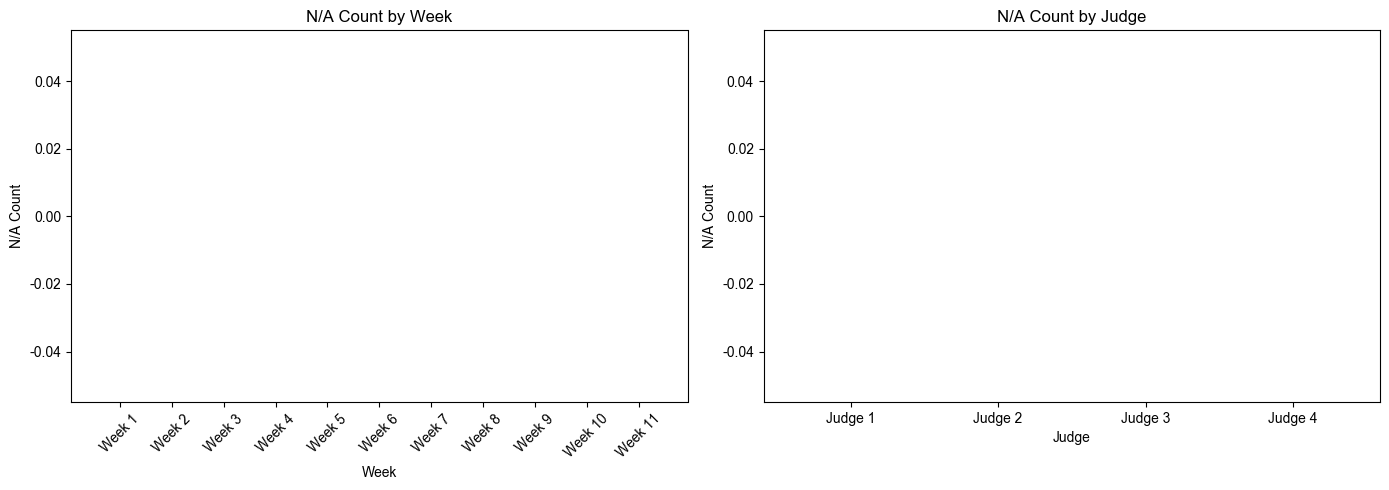

观察：Judge 4 的N/A最多，说明大多数赛季只有3位评委


In [7]:
# 可视化得分列的N/A分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按周统计N/A数量
na_by_week = {}
for week in range(1, 12):
    week_cols = [col for col in score_cols if f'week{week}_' in col]
    na_count = sum((df[col] == 'N/A').sum() for col in week_cols)
    na_by_week[f'Week {week}'] = na_count

axes[0].bar(na_by_week.keys(), na_by_week.values(), color='coral')
axes[0].set_title('N/A Count by Week')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('N/A Count')
axes[0].tick_params(axis='x', rotation=45)

# 按评委统计N/A数量 (Judge 4应该最多)
na_by_judge = {}
for judge in range(1, 5):
    judge_cols = [col for col in score_cols if f'judge{judge}_' in col]
    na_count = sum((df[col] == 'N/A').sum() for col in judge_cols)
    na_by_judge[f'Judge {judge}'] = na_count

axes[1].bar(na_by_judge.keys(), na_by_judge.values(), color='steelblue')
axes[1].set_title('N/A Count by Judge')
axes[1].set_xlabel('Judge')
axes[1].set_ylabel('N/A Count')

plt.tight_layout()
plt.savefig('fig1_na_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("观察：Judge 4 的N/A最多，说明大多数赛季只有3位评委")

### 2.1 元数据缺失分析

In [8]:
# 检查 celebrity_homestate 缺失情况
# 缺失原因：非美国选手
missing_homestate = df[df['celebrity_homestate'].isnull() | (df['celebrity_homestate'] == '')]
print(f"celebrity_homestate 缺失数: {len(missing_homestate)}")
print(f"\n这些选手的国家/地区分布:")
print(missing_homestate['celebrity_homecountry/region'].value_counts())

celebrity_homestate 缺失数: 56

这些选手的国家/地区分布:
celebrity_homecountry/region
England           11
Canada             9
Australia          4
Czechoslovakia     3
Mexico             3
Italy              3
Chile              2
France             2
Brazil             2
Russia             2
New Zealand        1
Yugoslavia         1
Poland             1
Cuba               1
South Korea        1
Germany            1
Wales              1
Croatia            1
Spain              1
South Africa       1
Philippines        1
Argentina          1
Ireland            1
Taiwan China       1
Venezuela          1
Name: count, dtype: int64


In [9]:
# 检查年龄缺失
age_missing = df[df['celebrity_age_during_season'].isnull()]
print(f"年龄缺失数: {len(age_missing)}")
if len(age_missing) > 0:
    print(age_missing[['celebrity_name', 'season']])

年龄缺失数: 0


## 第三步：赛季差异分析

需要分析各季在以下方面的差异：
1. 参赛人数
2. 播出周数
3. 评委人数

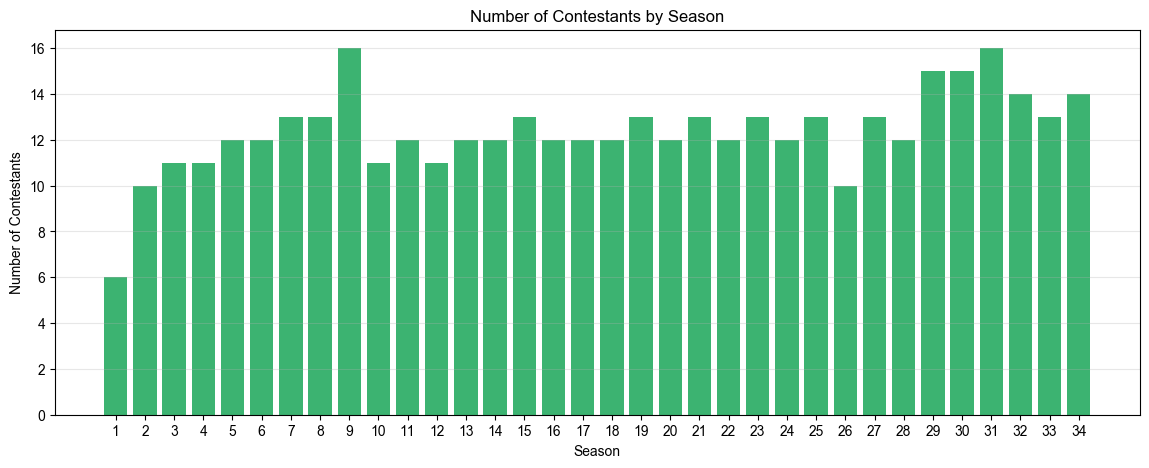


参赛人数统计:
  最少: 第1季 (6人)
  最多: 第9季 (16人)
  平均: 12.4人


In [10]:
# 按赛季统计参赛人数
contestants_per_season = df.groupby('season').size()

plt.figure(figsize=(14, 5))
plt.bar(contestants_per_season.index, contestants_per_season.values, color='mediumseagreen')
plt.xlabel('Season')
plt.ylabel('Number of Contestants')
plt.title('Number of Contestants by Season')
plt.xticks(range(1, 35))
plt.grid(axis='y', alpha=0.3)
plt.savefig('fig2_contestants_per_season.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n参赛人数统计:")
print(f"  最少: 第{contestants_per_season.idxmin()}季 ({contestants_per_season.min()}人)")
print(f"  最多: 第{contestants_per_season.idxmax()}季 ({contestants_per_season.max()}人)")
print(f"  平均: {contestants_per_season.mean():.1f}人")

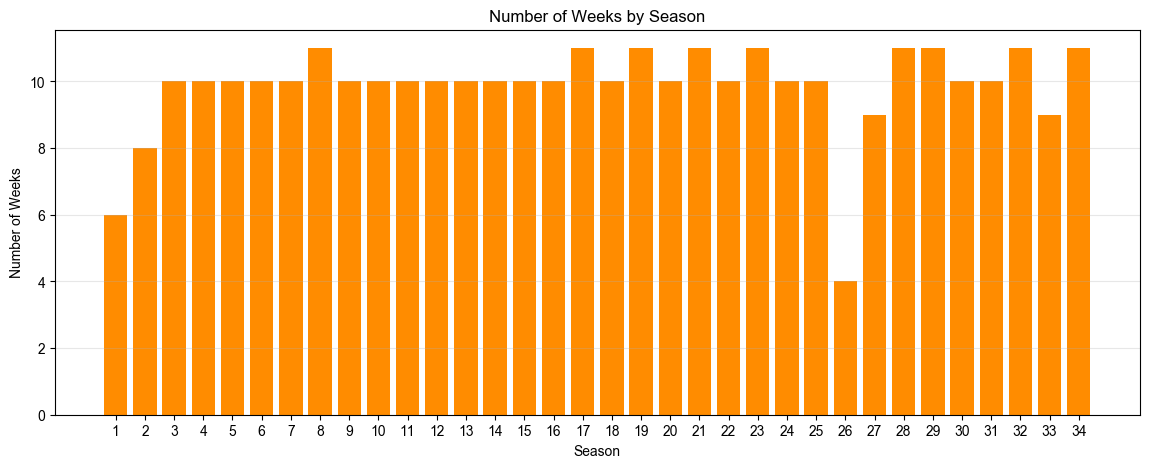


播出周数统计:
  最少: 第26季 (4周)
  最多: 第8季 (11周)


In [11]:
def count_active_weeks(row):
    """统计选手参赛周数（非N/A且非0的周数）"""
    active_weeks = 0
    for week in range(1, 12):
        week_cols = [f'week{week}_judge{j}_score' for j in range(1, 5)]
        # 检查该周是否有有效得分
        has_valid_score = False
        for col in week_cols:
            val = row[col]
            if val != 'N/A' and val != 0 and pd.notna(val):
                try:
                    if float(val) > 0:
                        has_valid_score = True
                        break
                except:
                    pass
        if has_valid_score:
            active_weeks += 1
    return active_weeks

def count_season_weeks(season_df):
    """统计赛季播出周数"""
    max_weeks = 0
    for week in range(1, 12):
        week_cols = [f'week{week}_judge{j}_score' for j in range(1, 4)]  # 只检查前3个评委
        # 检查是否有任何有效得分
        for _, row in season_df.iterrows():
            for col in week_cols:
                val = row[col]
                if val != 'N/A' and pd.notna(val):
                    try:
                        if float(val) > 0 or float(val) == 0:  # 0也是有效的（表示已淘汰）
                            max_weeks = max(max_weeks, week)
                            break
                    except:
                        pass
            else:
                continue
            break
    return max_weeks

# 计算每个赛季的播出周数
weeks_per_season = {}
for season in df['season'].unique():
    season_df = df[df['season'] == season]
    max_week = 0
    for week in range(1, 12):
        col = f'week{week}_judge1_score'
        # 检查该周是否有非N/A的得分
        non_na = season_df[col].apply(lambda x: x != 'N/A' and pd.notna(x)).any()
        if non_na:
            max_week = week
    weeks_per_season[season] = max_week

weeks_df = pd.DataFrame(list(weeks_per_season.items()), columns=['season', 'weeks']).sort_values('season')

plt.figure(figsize=(14, 5))
plt.bar(weeks_df['season'], weeks_df['weeks'], color='darkorange')
plt.xlabel('Season')
plt.ylabel('Number of Weeks')
plt.title('Number of Weeks by Season')
plt.xticks(range(1, 35))
plt.grid(axis='y', alpha=0.3)
plt.savefig('fig3_weeks_per_season.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n播出周数统计:")
print(f"  最少: 第{weeks_df.loc[weeks_df['weeks'].idxmin(), 'season']}季 ({weeks_df['weeks'].min()}周)")
print(f"  最多: 第{weeks_df.loc[weeks_df['weeks'].idxmax(), 'season']}季 ({weeks_df['weeks'].max()}周)")

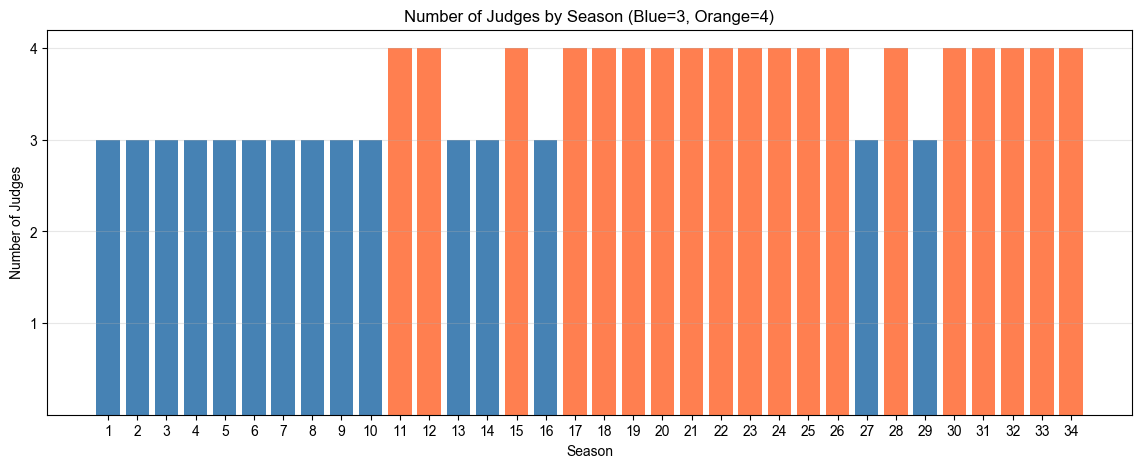


评委人数统计:
  3位评委的赛季数: 15
  4位评委的赛季数: 19


In [12]:
# 统计每个赛季的评委人数（检查judge4是否全为N/A）
def count_judges_per_season(season_df):
    """统计赛季的评委人数"""
    judges_count = []
    for week in range(1, 12):
        for judge in range(1, 5):
            col = f'week{week}_judge{judge}_score'
            # 检查是否有非N/A的值
            has_valid = season_df[col].apply(lambda x: x != 'N/A' and pd.notna(x)).any()
            if has_valid:
                judges_count.append((week, judge))
    
    # 找出每周的最大评委数
    if not judges_count:
        return 0
    max_judge = max(j for w, j in judges_count)
    return max_judge

judges_per_season = {}
for season in sorted(df['season'].unique()):
    season_df = df[df['season'] == season]
    judges_per_season[season] = count_judges_per_season(season_df)

judges_df = pd.DataFrame(list(judges_per_season.items()), columns=['season', 'judges'])

plt.figure(figsize=(14, 5))
colors = ['steelblue' if j == 3 else 'coral' for j in judges_df['judges']]
plt.bar(judges_df['season'], judges_df['judges'], color=colors)
plt.xlabel('Season')
plt.ylabel('Number of Judges')
plt.title('Number of Judges by Season (Blue=3, Orange=4)')
plt.xticks(range(1, 35))
plt.yticks([1, 2, 3, 4])
plt.grid(axis='y', alpha=0.3)
plt.savefig('fig4_judges_per_season.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n评委人数统计:")
print(f"  3位评委的赛季数: {(judges_df['judges'] == 3).sum()}")
print(f"  4位评委的赛季数: {(judges_df['judges'] == 4).sum()}")

In [13]:
# 创建赛季差异汇总表
season_summary = pd.DataFrame({
    'season': sorted(df['season'].unique()),
    'contestants': [contestants_per_season[s] for s in sorted(df['season'].unique())],
    'weeks': [weeks_per_season[s] for s in sorted(df['season'].unique())],
    'judges': [judges_per_season[s] for s in sorted(df['season'].unique())]
})

# 添加投票结合方式（根据题目说明）
def get_voting_method(season):
    if season in [1, 2]:
        return 'rank'
    elif season >= 28:
        return 'rank'  # 假设28季起恢复排名制
    else:
        return 'percentage'

season_summary['voting_method'] = season_summary['season'].apply(get_voting_method)

# 第15季是全明星季
season_summary['is_allstar'] = season_summary['season'] == 15

print("赛季差异汇总:")
season_summary

赛季差异汇总:


,season,contestants,weeks,judges,voting_method,is_allstar
0,1,6,6,3,rank,False
1,2,10,8,3,rank,False
2,3,11,10,3,percentage,False
3,4,11,10,3,percentage,False
4,5,12,10,3,percentage,False
5,6,12,10,3,percentage,False
6,7,13,10,3,percentage,False
7,8,13,11,3,percentage,False
8,9,16,10,3,percentage,False
9,10,11,10,3,percentage,False


## 第四步：评分尺度分析

评委打分范围为1-10，但存在以下特殊情况：
1. 小数得分：多个舞蹈的平均值（如8.5）
2. 加分情况：舞蹈对决等奖励分平均分配
3. 团队舞蹈得分：与个人得分取平均

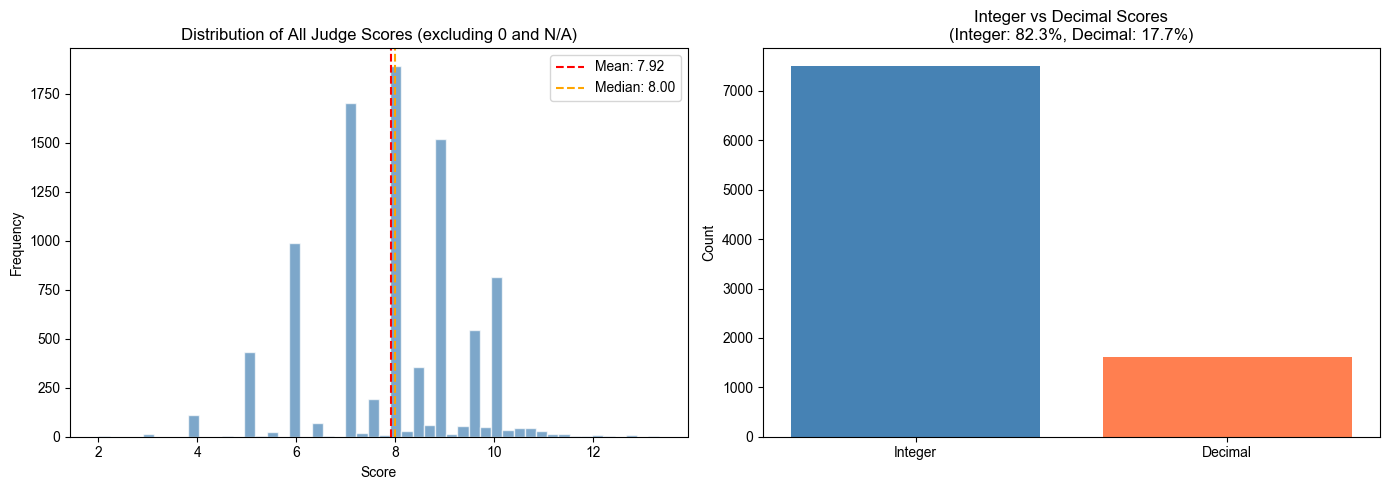


得分统计:
  最小值: 2.0
  最大值: 13.3333
  平均值: 7.92
  中位数: 8.00
  标准差: 1.50


In [14]:
# 将得分列转换为数值，N/A转为NaN
df_numeric = df.copy()
for col in score_cols:
    df_numeric[col] = pd.to_numeric(df_numeric[col].replace('N/A', np.nan), errors='coerce')

# 统计得分分布
all_scores = []
for col in score_cols:
    scores = df_numeric[col].dropna()
    scores = scores[scores > 0]  # 排除0分（已淘汰）
    all_scores.extend(scores.tolist())

all_scores = pd.Series(all_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 整体得分分布
axes[0].hist(all_scores, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of All Judge Scores (excluding 0 and N/A)')
axes[0].axvline(all_scores.mean(), color='red', linestyle='--', label=f'Mean: {all_scores.mean():.2f}')
axes[0].axvline(all_scores.median(), color='orange', linestyle='--', label=f'Median: {all_scores.median():.2f}')
axes[0].legend()

# 整数vs小数得分
is_integer = all_scores.apply(lambda x: x == int(x))
integer_scores = all_scores[is_integer]
decimal_scores = all_scores[~is_integer]

axes[1].bar(['Integer', 'Decimal'], [len(integer_scores), len(decimal_scores)], color=['steelblue', 'coral'])
axes[1].set_ylabel('Count')
axes[1].set_title(f'Integer vs Decimal Scores\n(Integer: {len(integer_scores)/len(all_scores)*100:.1f}%, Decimal: {len(decimal_scores)/len(all_scores)*100:.1f}%)')

plt.tight_layout()
plt.savefig('fig5_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n得分统计:")
print(f"  最小值: {all_scores.min()}")
print(f"  最大值: {all_scores.max()}")
print(f"  平均值: {all_scores.mean():.2f}")
print(f"  中位数: {all_scores.median():.2f}")
print(f"  标准差: {all_scores.std():.2f}")

In [15]:
# 分析小数得分的分布
print("小数得分的常见值（可能是多舞蹈平均）:")
decimal_value_counts = decimal_scores.value_counts().head(20)
print(decimal_value_counts)

# 检查是否有超出1-10范围的得分
out_of_range = all_scores[(all_scores < 1) | (all_scores > 10)]
print(f"\n超出1-10范围的得分数: {len(out_of_range)}")
if len(out_of_range) > 0:
    print(f"这些得分: {out_of_range.unique()}")

小数得分的常见值（可能是多舞蹈平均）:
9.50     454
8.50     356
7.50     189
9.67      86
6.50      63
9.33      45
10.50     43
8.67      41
9.75      34
5.50      22
10.75     20
10.67     19
8.33      16
10.25     15
10.33     15
11.33     15
8.75      14
9.78      14
11.25     11
9.25      10
Name: count, dtype: int64

超出1-10范围的得分数: 221
这些得分: [11.3333 10.3333 10.6666 10.5    10.125  10.375  10.25   10.625  10.875
 11.     12.3333 12.     12.6666 13.3333 11.6666 13.     11.25   11.1666
 10.8333 10.75   11.8333 12.8333 12.5    10.4444]


## 第五步：特殊事件分析

需要识别以下特殊事件：
1. 中途退赛 (Withdrew)
2. 无淘汰周
3. 双淘汰周

In [16]:
# 分析results列的所有类型
print("所有比赛结果类型:")
results_counts = df['results'].value_counts()
print(results_counts)

所有比赛结果类型:
results
Eliminated Week 2     40
Eliminated Week 8     36
Eliminated Week 7     36
Eliminated Week 4     35
2nd Place             34
3rd Place             34
1st Place             34
Eliminated Week 3     33
Eliminated Week 9     32
Eliminated Week 6     31
Eliminated Week 5     24
Eliminated Week 1     16
Eliminated Week 10    11
Withdrew              10
4th Place              8
Eliminated Week 11     4
5th Place              3
Name: count, dtype: int64


In [17]:
# 识别退赛选手
withdrew = df[df['results'].str.contains('Withdrew', case=False, na=False)]
print(f"中途退赛选手数: {len(withdrew)}")
if len(withdrew) > 0:
    print("\n退赛选手详情:")
    print(withdrew[['celebrity_name', 'season', 'results', 'placement']])

中途退赛选手数: 10

退赛选手详情:
           celebrity_name  season   results  placement
24             Sara Evans       3  Withdrew          6
66      Misty May-Treanor       7  Withdrew         10
98              Tom DeLay       9  Withdrew         13
177        Dorothy Hamill      16  Withdrew         12
199    Billy Dee Williams      18  Withdrew         10
243         Tamar Braxton      21  Withdrew          5
247  Kim Zolciak-Biermann      21  Withdrew         11
325             Ray Lewis      28  Withdrew         11
348           Jeannie Mai      29  Withdrew          9
366           Selma Blair      31  Withdrew         12


In [18]:
# 分析每季每周的淘汰情况，识别无淘汰周和双淘汰周
def analyze_eliminations(df):
    """分析淘汰模式"""
    eliminations = []
    
    for season in sorted(df['season'].unique()):
        season_df = df[df['season'] == season]
        
        for week in range(1, 12):
            # 找出在该周被淘汰的选手（results包含 "Eliminated Week X"）
            eliminated_this_week = season_df[
                season_df['results'].str.contains(f'Eliminated Week {week}', case=False, na=False) |
                season_df['results'].str.contains(f'Eliminated week {week}', case=False, na=False)
            ]
            
            # 检查是否该季有这一周
            week_col = f'week{week}_judge1_score'
            if week_col in season_df.columns:
                has_week = not (season_df[week_col] == 'N/A').all()
            else:
                has_week = False
            
            if has_week:
                eliminations.append({
                    'season': season,
                    'week': week,
                    'eliminated_count': len(eliminated_this_week),
                    'eliminated_names': ', '.join(eliminated_this_week['celebrity_name'].tolist())
                })
    
    return pd.DataFrame(eliminations)

eliminations_df = analyze_eliminations(df)

# 找出无淘汰周（eliminated_count == 0）
no_elimination_weeks = eliminations_df[eliminations_df['eliminated_count'] == 0]
print(f"无淘汰周数量: {len(no_elimination_weeks)}")

# 找出双淘汰周（eliminated_count >= 2）
double_elimination_weeks = eliminations_df[eliminations_df['eliminated_count'] >= 2]
print(f"\n双淘汰（或更多）周数量: {len(double_elimination_weeks)}")
if len(double_elimination_weeks) > 0:
    print("\n双淘汰周详情:")
    print(double_elimination_weeks[['season', 'week', 'eliminated_count', 'eliminated_names']])

无淘汰周数量: 100

双淘汰（或更多）周数量: 37

双淘汰周详情:
     season  week  eliminated_count  \
56        6     2                 2   
66        7     1                 2   
80        8     4                 2   
88        9     1                 2   
93        9     6                 2   
94        9     7                 2   
150      14     8                 2   
156      15     3                 2   
161      15     8                 2   
162      15     9                 2   
176      17     1                 2   
188      18     2                 2   
198      19     1                 3   
216      20     8                 2   
221      21     2                 2   
237      22     7                 2   
239      22     9                 2   
242      23     1                 2   
245      23     4                 2   
259      24     7                 2   
265      25     2                 2   
270      25     7                 2   
275      26     1                 2   
276      26     2         

In [19]:
# 创建特殊事件标记
# 标记退赛选手
df_numeric['is_withdrew'] = df['results'].str.contains('Withdrew', case=False, na=False)

# 标记争议选手（根据题目提到的）
controversial_contestants = [
    ('Jerry Rice', 2),
    ('Billy Ray Cyrus', 4),
    ('Bristol Palin', 11),
    ('Bobby Bones', 27)
]

df_numeric['is_controversial'] = df_numeric.apply(
    lambda row: (row['celebrity_name'], row['season']) in controversial_contestants, axis=1
)

print(f"退赛选手数: {df_numeric['is_withdrew'].sum()}")
print(f"争议选手数: {df_numeric['is_controversial'].sum()}")

退赛选手数: 10
争议选手数: 4


## 第六步：数据清洗与特征工程

In [20]:
# 创建清洗后的数据集
df_clean = df_numeric.copy()

# 1. 处理 celebrity_homestate 缺失值：非美国选手标记为 'Non-US'
df_clean['celebrity_homestate'] = df_clean['celebrity_homestate'].fillna('Non-US')
df_clean.loc[df_clean['celebrity_homestate'] == '', 'celebrity_homestate'] = 'Non-US'

# 2. 添加赛季元数据
df_clean = df_clean.merge(season_summary, on='season', how='left')

# 3. 计算每位选手的参赛周数
def calc_active_weeks(row):
    weeks = 0
    for week in range(1, 12):
        col = f'week{week}_judge1_score'
        val = row[col]
        if pd.notna(val) and val > 0:
            weeks += 1
    return weeks

df_clean['active_weeks'] = df_clean.apply(calc_active_weeks, axis=1)

# 4. 计算每周总分和平均分
for week in range(1, 12):
    judge_cols = [f'week{week}_judge{j}_score' for j in range(1, 5)]
    # 周总分（排除NaN）
    df_clean[f'week{week}_total'] = df_clean[judge_cols].sum(axis=1, skipna=True)
    # 周平均分（排除NaN）
    df_clean[f'week{week}_avg'] = df_clean[judge_cols].mean(axis=1, skipna=True)

# 5. 计算整体平均分（排除0分和NaN）
def calc_overall_avg(row):
    scores = []
    for week in range(1, 12):
        for judge in range(1, 5):
            col = f'week{week}_judge{judge}_score'
            val = row[col]
            if pd.notna(val) and val > 0:
                scores.append(val)
    return np.mean(scores) if scores else np.nan

df_clean['overall_avg_score'] = df_clean.apply(calc_overall_avg, axis=1)

print("特征工程完成!")
print(f"\n新增特征:")
print(f"  - active_weeks: 参赛周数")
print(f"  - week1-11_total: 每周总分")
print(f"  - week1-11_avg: 每周平均分")
print(f"  - overall_avg_score: 整体平均得分")

特征工程完成!

新增特征:
  - active_weeks: 参赛周数
  - week1-11_total: 每周总分
  - week1-11_avg: 每周平均分
  - overall_avg_score: 整体平均得分


In [21]:
# 6. 解析淘汰周次
def parse_elimination_week(result):
    """从results中解析淘汰周次"""
    if pd.isna(result):
        return np.nan
    result = str(result)
    if 'Place' in result or 'place' in result:
        return np.nan  # 进入决赛
    if 'Withdrew' in result:
        return -1  # 退赛
    if 'Eliminated Week' in result or 'Eliminated week' in result:
        try:
            week = int(result.split('Week')[-1].split('week')[-1].strip())
            return week
        except:
            return np.nan
    return np.nan

df_clean['elimination_week'] = df_clean['results'].apply(parse_elimination_week)

# 7. 标记是否进入决赛（前3名）
df_clean['is_finalist'] = df_clean['placement'] <= 3

# 8. 解析名次
def parse_placement_rank(result):
    """从results中解析排名"""
    if pd.isna(result):
        return np.nan
    result = str(result)
    if '1st Place' in result:
        return 1
    elif '2nd Place' in result:
        return 2
    elif '3rd Place' in result:
        return 3
    return np.nan

df_clean['final_rank'] = df_clean['results'].apply(parse_placement_rank)

print("淘汰信息解析完成!")

淘汰信息解析完成!


In [22]:
# 验证数据
print("数据验证:")
print(f"  总行数: {len(df_clean)}")
print(f"  总列数: {len(df_clean.columns)}")
print(f"\n元数据缺失检查:")
for col in ['celebrity_name', 'ballroom_partner', 'celebrity_industry', 'season', 'placement']:
    missing = df_clean[col].isnull().sum()
    print(f"  {col}: {missing} 缺失")

数据验证:
  总行数: 421
  总列数: 87

元数据缺失检查:
  celebrity_name: 0 缺失
  ballroom_partner: 0 缺失
  celebrity_industry: 0 缺失
  season: 0 缺失
  placement: 0 缺失


In [23]:
# 查看清洗后的数据
df_clean.head()

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,week1_judge2_score,week1_judge3_score,week1_judge4_score,week2_judge1_score,week2_judge2_score,week2_judge3_score,week2_judge4_score,week3_judge1_score,week3_judge2_score,week3_judge3_score,week3_judge4_score,week4_judge1_score,week4_judge2_score,week4_judge3_score,week4_judge4_score,week5_judge1_score,week5_judge2_score,week5_judge3_score,week5_judge4_score,week6_judge1_score,...,judges,voting_method,is_allstar,active_weeks,week1_total,week1_avg,week2_total,week2_avg,week3_total,week3_avg,week4_total,week4_avg,week5_total,week5_avg,week6_total,week6_avg,week7_total,week7_avg,week8_total,week8_avg,week9_total,week9_avg,week10_total,week10_avg,week11_total,week11_avg,overall_avg_score,elimination_week,is_finalist,final_rank
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.00,7.00,6.00,NaN,8.00,9.00,9.00,NaN,9.00,8.00,7.00,NaN,7.00,8.00,6.00,NaN,9.00,9.00,9.00,NaN,9.00,...,3,rank,False,6,20.00,6.67,26.00,8.67,24.00,8.00,21.00,7.00,27.00,9.00,27.00,9.00,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,8.06,NaN,True,2.00
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.00,4.00,4.00,NaN,5.00,6.00,6.00,NaN,6.00,7.00,8.00,NaN,9.00,9.00,8.00,NaN,8.50,7.50,7.50,NaN,8.50,...,3,rank,False,6,13.00,4.33,17.00,5.67,21.00,7.00,26.00,8.67,23.50,7.83,27.50,9.17,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,7.11,NaN,True,1.00
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.00,7.00,6.00,NaN,5.00,4.00,5.00,NaN,5.00,4.00,4.00,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,NaN,0.00,...,3,rank,False,3,18.00,6.00,14.00,4.67,13.00,4.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,5.00,3.00,False,NaN
3,Rachel Hunter,Jonathan Roberts,Model,Non-US,New Zealand,35,1,Eliminated Week 4,4,7.00,6.00,7.00,NaN,8.00,8.00,8.00,NaN,8.00,9.00,9.00,NaN,7.00,9.00,9.00,NaN,0.00,0.00,0.00,NaN,0.00,...,3,rank,False,4,20.00,6.67,24.00,8.00,26.00,8.67,25.00,8.33,0.00,0.00,0.00,0.00,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,7.92,4.00,False,NaN
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.00,7.00,6.00,NaN,8.00,7.00,6.00,NaN,7.00,7.00,8.00,NaN,7.00,6.00,7.00,NaN,8.50,7.00,7.00,NaN,0.00,...,3,rank,False,5,20.00,6.67,21.00,7.00,22.00,7.33,20.00,6.67,22.50,7.50,0.00,0.00,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,7.03,NaN,True,3.00


## 第七步：EDA可视化

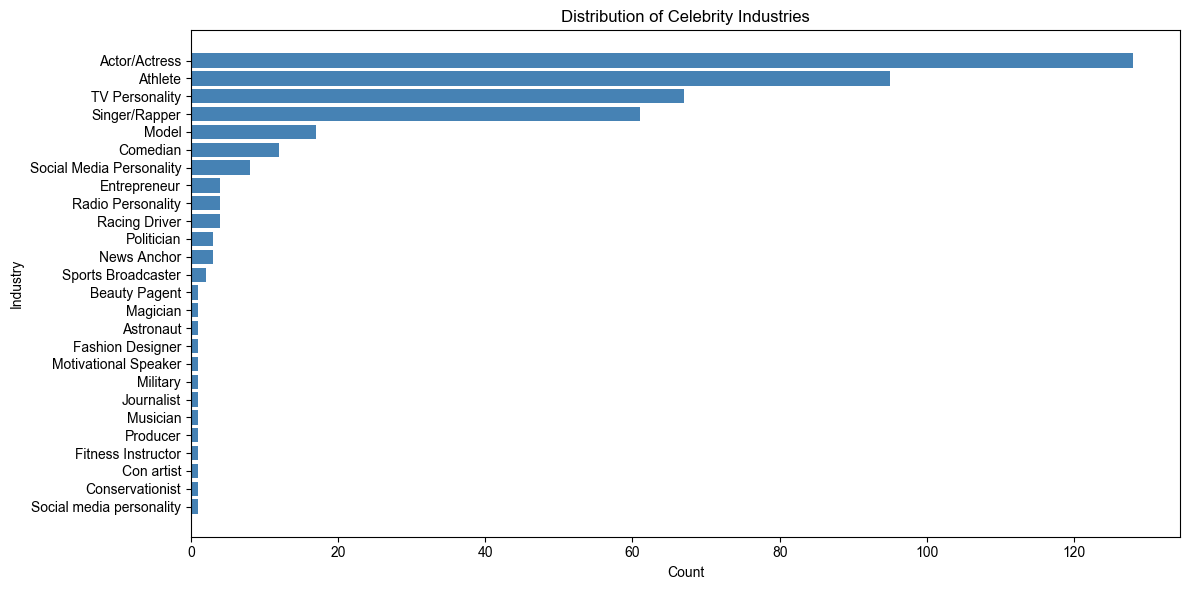

In [24]:
# 行业分布
plt.figure(figsize=(12, 6))
industry_counts = df_clean['celebrity_industry'].value_counts()
plt.barh(industry_counts.index, industry_counts.values, color='steelblue')
plt.xlabel('Count')
plt.ylabel('Industry')
plt.title('Distribution of Celebrity Industries')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig6_industry_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

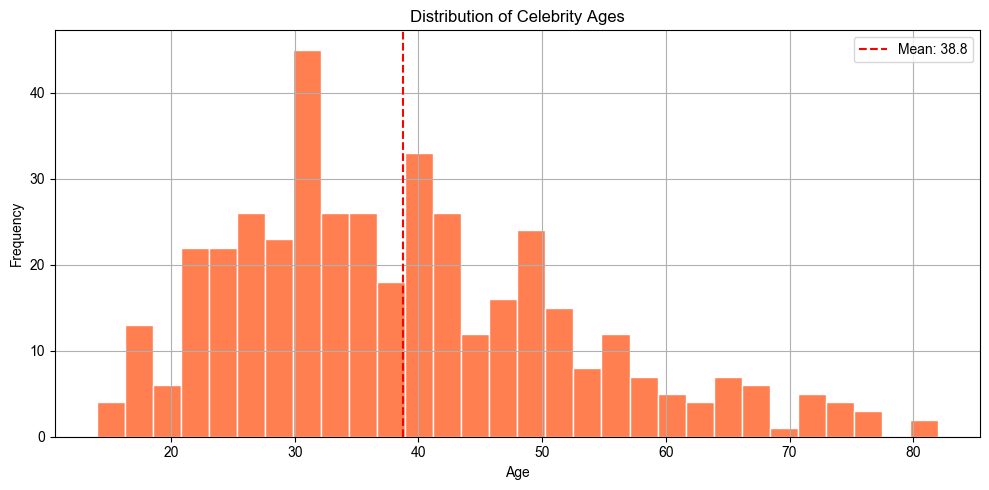

年龄统计:
  最小: 14
  最大: 82
  平均: 38.8


In [25]:
# 年龄分布
plt.figure(figsize=(10, 5))
df_clean['celebrity_age_during_season'].hist(bins=30, color='coral', edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Celebrity Ages')
plt.axvline(df_clean['celebrity_age_during_season'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df_clean["celebrity_age_during_season"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.savefig('fig7_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"年龄统计:")
print(f"  最小: {df_clean['celebrity_age_during_season'].min()}")
print(f"  最大: {df_clean['celebrity_age_during_season'].max()}")
print(f"  平均: {df_clean['celebrity_age_during_season'].mean():.1f}")

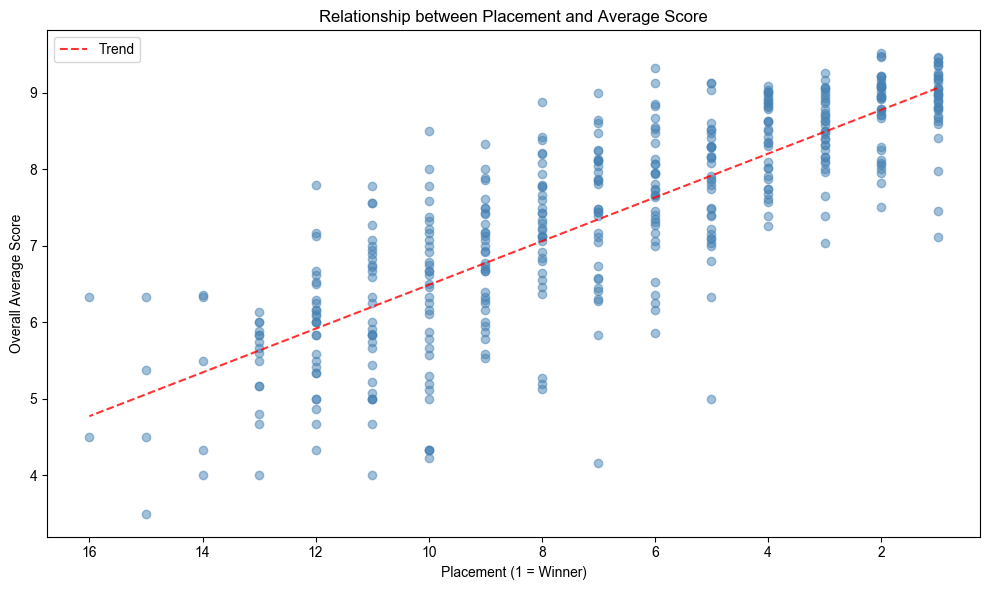

排名与平均得分相关系数: -0.805
（负相关：得分越高，排名越靠前）


In [26]:
# 平均得分与最终排名的关系
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['placement'], df_clean['overall_avg_score'], alpha=0.5, color='steelblue')
plt.xlabel('Placement (1 = Winner)')
plt.ylabel('Overall Average Score')
plt.title('Relationship between Placement and Average Score')
plt.gca().invert_xaxis()  # 1在右边

# 添加趋势线
z = np.polyfit(df_clean['placement'].dropna(), df_clean.loc[df_clean['placement'].notna(), 'overall_avg_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['placement'].min(), df_clean['placement'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', alpha=0.8, label='Trend')
plt.legend()

plt.tight_layout()
plt.savefig('fig8_placement_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()

# 计算相关系数
corr = df_clean['placement'].corr(df_clean['overall_avg_score'])
print(f"排名与平均得分相关系数: {corr:.3f}")
print("（负相关：得分越高，排名越靠前）")

In [27]:
# 分析争议选手的得分排名情况
print("争议选手分析:")
print("="*60)

for name, season in controversial_contestants:
    contestant = df_clean[(df_clean['celebrity_name'] == name) & (df_clean['season'] == season)]
    if len(contestant) > 0:
        row = contestant.iloc[0]
        print(f"\n{name} (Season {season}):")
        print(f"  最终排名: {row['placement']}")
        print(f"  平均得分: {row['overall_avg_score']:.2f}")
        
        # 计算该季的得分排名
        season_df = df_clean[df_clean['season'] == season]
        avg_rank = (season_df['overall_avg_score'] > row['overall_avg_score']).sum() + 1
        print(f"  该季得分排名: {avg_rank}/{len(season_df)}")

争议选手分析:

Jerry Rice (Season 2):
  最终排名: 2
  平均得分: 7.51
  该季得分排名: 6/10

Billy Ray Cyrus (Season 4):
  最终排名: 5
  平均得分: 6.33
  该季得分排名: 9/11

Bristol Palin (Season 11):
  最终排名: 3
  平均得分: 7.39
  该季得分排名: 7/12

Bobby Bones (Season 27):
  最终排名: 1
  平均得分: 7.46
  该季得分排名: 8/13


## 第八步：保存处理后的数据

In [28]:
# 保存完整的处理后数据
df_clean.to_csv('data_processed.csv', index=False)
print("✅ 完整数据已保存至: data_processed.csv")

# 保存赛季汇总数据
season_summary.to_csv('season_summary.csv', index=False)
print("✅ 赛季汇总已保存至: season_summary.csv")

# 保存淘汰分析数据
eliminations_df.to_csv('eliminations_by_week.csv', index=False)
print("✅ 淘汰分析已保存至: eliminations_by_week.csv")

✅ 完整数据已保存至: data_processed.csv
✅ 赛季汇总已保存至: season_summary.csv
✅ 淘汰分析已保存至: eliminations_by_week.csv


In [29]:
# 最终数据质量报告
print("="*60)
print("数据预处理完成 - 最终报告")
print("="*60)
print(f"\n数据规模:")
print(f"  - 参赛者总数: {len(df_clean)}")
print(f"  - 赛季数: {df_clean['season'].nunique()}")
print(f"  - 特征列数: {len(df_clean.columns)}")

print(f"\n赛季差异:")
print(f"  - 参赛人数范围: {season_summary['contestants'].min()}-{season_summary['contestants'].max()}")
print(f"  - 播出周数范围: {season_summary['weeks'].min()}-{season_summary['weeks'].max()}")
print(f"  - 评委人数: 3位({(season_summary['judges']==3).sum()}季) / 4位({(season_summary['judges']==4).sum()}季)")

print(f"\n投票方式:")
print(f"  - 排名制(rank): 第1-2季, 第28-34季")
print(f"  - 百分比制(percentage): 第3-27季")

print(f"\n特殊事件:")
print(f"  - 退赛选手数: {df_clean['is_withdrew'].sum()}")
print(f"  - 争议选手数: {df_clean['is_controversial'].sum()}")
print(f"  - 全明星季: 第15季")
print(f"  - 双淘汰周数: {len(double_elimination_weeks)}")

print(f"\n评分统计:")
print(f"  - 得分范围: 1-10")
print(f"  - 平均得分: {df_clean['overall_avg_score'].mean():.2f}")
print(f"  - 含小数得分的比例: {len(decimal_scores)/len(all_scores)*100:.1f}%")

数据预处理完成 - 最终报告

数据规模:
  - 参赛者总数: 421
  - 赛季数: 34
  - 特征列数: 87

赛季差异:
  - 参赛人数范围: 6-16
  - 播出周数范围: 4-11
  - 评委人数: 3位(15季) / 4位(19季)

投票方式:
  - 排名制(rank): 第1-2季, 第28-34季
  - 百分比制(percentage): 第3-27季

特殊事件:
  - 退赛选手数: 10
  - 争议选手数: 4
  - 全明星季: 第15季
  - 双淘汰周数: 37

评分统计:
  - 得分范围: 1-10
  - 平均得分: 7.40
  - 含小数得分的比例: 17.7%


## 附录：数据字典

### 原始字段
| 字段 | 说明 |
|------|------|
| celebrity_name | 明星姓名 |
| ballroom_partner | 专业舞者搭档 |
| celebrity_industry | 职业类别 |
| celebrity_homestate | 所在州（非美国为'Non-US'） |
| celebrity_homecountry/region | 国家/地区 |
| celebrity_age_during_season | 参赛时年龄 |
| season | 赛季 |
| results | 比赛结果 |
| placement | 最终排名 |
| weekX_judgeY_score | 第X周第Y评委得分 |

### 新增字段
| 字段 | 说明 |
|------|------|
| contestants | 该季参赛人数 |
| weeks | 该季播出周数 |
| judges | 该季评委人数 |
| voting_method | 投票结合方式(rank/percentage) |
| is_allstar | 是否全明星季 |
| active_weeks | 选手参赛周数 |
| weekX_total | 第X周总分 |
| weekX_avg | 第X周平均分 |
| overall_avg_score | 整体平均得分 |
| elimination_week | 淘汰周次(-1为退赛) |
| is_finalist | 是否进入决赛 |
| final_rank | 决赛排名(1/2/3) |
| is_withdrew | 是否中途退赛 |
| is_controversial | 是否为争议选手 |